Importing Nessesery Packages

In [3]:
import math
from qiskit import QuantumCircuit
from qiskit.primitives import StatevectorSampler as Sampler
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt

Building Circuit

In [4]:
qc = QuantumCircuit(3, 3)

Superposition

In [5]:
for i in range(3):
    qc.h(i)

The Oracle circuit for marked state 5

In [6]:
def oracle(circuit):
    circuit.barrier()

    # Target = |101> -> Qubit indices: q2=1, q1=0, q0=1
    # Flip q1 so the target state |101> turns into |111>
    circuit.x(1)

    # Multi-Controlled Z across the 3 qubits:
    # We turn an MCX into an MCZ by wrapping the target qubit (q2) in Hadamards
    circuit.h(2)
    circuit.mcx([0, 1], 2)
    circuit.h(2)

    # Undo the X gate
    circuit.x(1)

    circuit.barrier()

Diffusion Oporator

In [7]:
def diffusion(circuit):
    circuit.barrier()

    # Step 1: Apply H and X to all 3 qubits
    for i in range(3):
        circuit.h(i)
        circuit.x(i)

    # Step 2: Multi-Controlled Z (Phase shift for the |000> state)
    circuit.h(2)
    circuit.mcx([0, 1], 2)
    circuit.h(2)

    # Step 3: Undo X and H gates
    for i in range(3):
        circuit.x(i)
        circuit.h(i)

    circuit.barrier()

In [8]:
N = 2**3
M = 1
repeat = round((math.pi / 4) * math.sqrt(N / M))

Constructing the full circuit

In [9]:
for _ in range(repeat):
    oracle(qc)
    diffusion(qc)

# 5. Measure all 3 qubits
qc.measure([0, 1, 2], [0, 1, 2])

In [10]:
sampler = Sampler()
job = sampler.run([qc], shots=1000)
result = job.result()

# Extract and plot counts automatically
pub_result = result[0]
counts = pub_result.data.c.get_counts()
print("Measurement Counts:", counts)

Measurement Counts: {'101': 939, '011': 9, '010': 4, '110': 12, '001': 6, '100': 6, '000': 14, '111': 10}


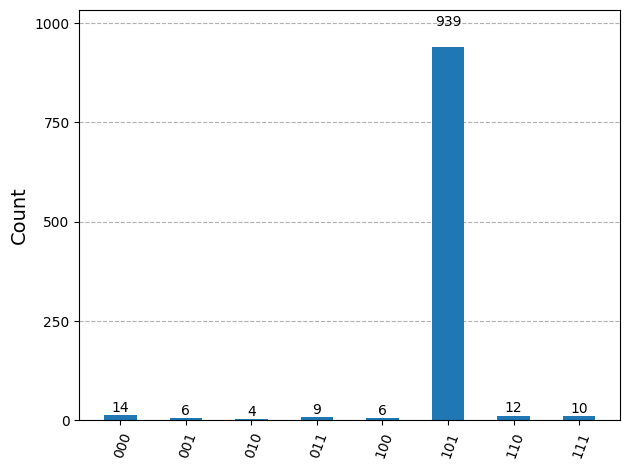

In [12]:
pub_result = result[0]
counts = pub_result.data.c.get_counts()
plot_histogram(counts)

In [13]:
qc.draw()

┌───┐ ░                 ░  ░ ┌───┐┌───┐          ┌───┐┌───┐      ░  ░ »
q_0: ┤ H ├─░────────■────────░──░─┤ H ├┤ X ├───────■──┤ X ├┤ H ├──────░──░─»
     ├───┤ ░ ┌───┐  │  ┌───┐ ░  ░ ├───┤├───┤       │  ├───┤├───┤      ░  ░ »
q_1: ┤ H ├─░─┤ X ├──■──┤ X ├─░──░─┤ H ├┤ X ├───────■──┤ X ├┤ H ├──────░──░─»
     ├───┤ ░ ├───┤┌─┴─┐├───┤ ░  ░ ├───┤├───┤┌───┐┌─┴─┐├───┤├───┤┌───┐ ░  ░ »
q_2: ┤ H ├─░─┤ H ├┤ X ├┤ H ├─░──░─┤ H ├┤ X ├┤ H ├┤ X ├┤ H ├┤ X ├┤ H ├─░──░─»
     └───┘ ░ └───┘└───┘└───┘ ░  ░ └───┘└───┘└───┘└───┘└───┘└───┘└───┘ ░  ░ »
c: 3/══════════════════════════════════════════════════════════════════════»
                                                                           »
«                     ░  ░ ┌───┐┌───┐          ┌───┐┌───┐      ░ ┌─┐      
«q_0: ───────■────────░──░─┤ H ├┤ X ├───────■──┤ X ├┤ H ├──────░─┤M├──────
«     ┌───┐  │  ┌───┐ ░  ░ ├───┤├───┤       │  ├───┤├───┤      ░ └╥┘┌─┐   
«q_1: ┤ X ├──■──┤ X ├─░──░─┤ H ├┤ X ├───────■──┤ X ├┤ H ├──────░──╫─┤M├───
«     ├───┤┌─┴─┐├───┤ ░  ░ ├───┤├───┤┌───┐┌─┴─┐├───┤├───┤┌───┐ ░  ║ └╥┘┌─┐
«q_2: ┤ H ├┤ X ├┤ H ├─░──░─┤ H ├┤ X ├┤ H ├┤ X ├┤ H ├┤ X ├┤ H ├─░──╫──╫─┤M├
«     └───┘└───┘└───┘ ░  ░ └───┘└───┘└───┘└───┘└───┘└───┘└───┘ ░  ║  ║ └╥┘
«c: 3/════════════════════════════════════════════════════════════╩══╩══╩═
«                                                                 0  1  2